In [1]:
import pandas as pd

final_df = pd.read_csv("final_provider_dataset.csv")

In [2]:
# assuming RF was best
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = final_df.drop(["Provider", "Fraud"], axis=1)
y = final_df["Fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

providers_test = final_df.loc[X_test.index, "Provider"]

In [3]:
results_df = pd.DataFrame({
    "Provider": providers_test.values,
    "TrueFraud": y_test.values,
    "PredFraud": y_pred,
    "FraudProb": y_prob
})

results_df["ErrorType"] = "Correct"
results_df.loc[(results_df["TrueFraud"]==0)&(results_df["PredFraud"]==1), "ErrorType"] = "False Positive"
results_df.loc[(results_df["TrueFraud"]==1)&(results_df["PredFraud"]==0), "ErrorType"] = "False Negative"

results_df.head()

,Provider,TrueFraud,PredFraud,FraudProb,ErrorType
0,PRV57101,0,1,0.57,False Positive
1,PRV54756,0,0,0.01,Correct
2,PRV53644,0,0,0.00,Correct
3,PRV53814,0,0,0.04,Correct
4,PRV53296,0,0,0.00,Correct


In [4]:
false_positives = results_df[results_df["ErrorType"]=="False Positive"].sort_values("FraudProb", ascending=False)
false_negatives = results_df[results_df["ErrorType"]=="False Negative"].sort_values("FraudProb")

false_positives.head(5)
false_negatives.head(5)

,Provider,TrueFraud,PredFraud,FraudProb,ErrorType
709,PRV57569,1,0,0.003333,False Negative
362,PRV57282,1,0,0.010000,False Negative
211,PRV57667,1,0,0.016667,False Negative
1311,PRV54505,1,0,0.023333,False Negative
1216,PRV57672,1,0,0.026667,False Negative


In [5]:
fp_provider = false_positives.iloc[0]["Provider"]
fn_provider = false_negatives.iloc[0]["Provider"]

final_df[final_df["Provider"] == fp_provider].T
final_df[final_df["Provider"] == fn_provider].T

,5248
Provider,PRV57569
inpatient_claim_count,5.0
inpatient_total_reimbursement,31000.0
inpatient_avg_reimbursement,6200.0
inpatient_unique_beneficiaries,4.0
outpatient_claim_count,68.0
outpatient_total_reimbursement,26940.0
outpatient_avg_reimbursement,396.176471
outpatient_unique_beneficiaries,58.0
avg_bene_chronic_count,17.451613


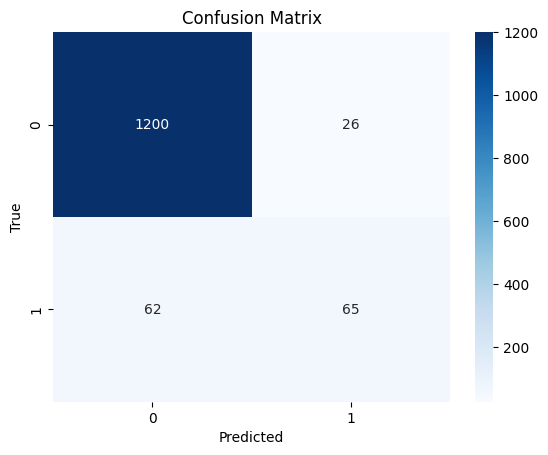

In [6]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()